In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np

from relaxedgp.schedules import ConstantSchedule
from relaxedgp_experiments.base import Experiment

/Users/scortino/.local/share/mamba/envs/relaxedgp-env/lib/python3.12/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
logger = logging.getLogger(__name__)
logging.basicConfig(stream=sys.stdout, level=logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

## W-SVGP

In [4]:
experiment_config = {
    "log_dir": "./",  # log figures, if any
    "dataset_name": "banana",
    "model_name": "wsvgp",
    "task": "classification",
    "kernel_name": "squared_exponential",
    "train_only": True,
    "origin": "openml",
    "normalize_data": False,
    "M": 64,
    "init_Z_method": "kmeans",
    "preconditioner": "identity",
}

In [5]:
run_config = {
    "n_iter": 10000,
    "adam_lr": 1e-2,
    "natgrad_schedule": ConstantSchedule(max_steps=1, value=1.0),
    "train_Z": False,
    "batch_size": 64,
    "evaluate_every": 1000,
    "debug_full_loss": True,
    "verbose": False,
}

In [6]:
experiment = Experiment(
    **experiment_config,
    logger=logger,
)

In [7]:
Z = experiment.model.inducing_variable

In [8]:
lmls_wsvgp = experiment.run(
    **run_config,
)

I0000 00:00:1775032515.739324 5057027 service.cc:145] XLA service 0x600000b37700 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775032515.739342 5057027 service.cc:153]   StreamExecutor device (0): Host, Default Version
2026-04-01 10:35:15.757764: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775032516.031435 5057027 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## L-SVGP

In [9]:
experiment_config["model_name"] = "lsvgp"

In [10]:
experiment = Experiment(
    **experiment_config,
    logger=logger,
)

In [11]:
experiment.model.inducing_variable = Z

In [12]:
lmls_lsvgp = experiment.run(
    **run_config,
)

## L-SVGP (P)

In [13]:
experiment_config["preconditioner"] = "inv"

In [14]:
experiment = Experiment(
    **experiment_config,
    logger=logger,
)

In [15]:
experiment.model.inducing_variable = Z

In [16]:
lmls_lsvgp_p = experiment.run(
    **run_config,
)

## R-SVGP (N)

In [17]:
experiment_config["model_name"] = "rsvgp_n"
experiment_config["preconditioner"] = "identity"

In [18]:
experiment = Experiment(
    **experiment_config,
    logger=logger,
)

In [19]:
experiment.model.inducing_variable = Z

In [20]:
lmls_rsvgp_n = experiment.run(
    **run_config,
)

## R-SVGP (NP)

In [21]:
experiment_config["preconditioner"] = "T"

In [22]:
experiment = Experiment(
    **experiment_config,
    logger=logger,
)

In [23]:
experiment.model.inducing_variable = Z

In [24]:
lmls_rsvgp_np = experiment.run(
    **run_config,
)

## R-SVGP

In [25]:
experiment_config["model_name"] = "rsvgp"
experiment_config["preconditioner"] = "identity"

In [26]:
experiment = Experiment(
    **experiment_config,
    logger=logger,
)

In [27]:
experiment.model.inducing_variable = Z

In [28]:
lmls_rsvgp = experiment.run(
    **run_config,
)

## R-SVGP (P)

In [29]:
experiment_config["preconditioner"] = "T"

In [30]:
experiment = Experiment(
    **experiment_config,
    logger=logger,
)

In [31]:
experiment.model.inducing_variable = Z

In [32]:
lmls_rsvgp_p = experiment.run(
    **run_config,
)

## Trace plot

In [33]:
lmls = [
    lmls_wsvgp,
    lmls_lsvgp,
    lmls_lsvgp_p,
    lmls_rsvgp,
    lmls_rsvgp_p,
    lmls_rsvgp_n,
    lmls_rsvgp_np,
]
methods = [
    "W-SVGP",
    "L-SVGP",
    "L-SVGP (P)",
    "R-SVGP",
    "R-SVGP (P)",
    "R-SVGP (N)",
    "R-SVGP (NP)",
]

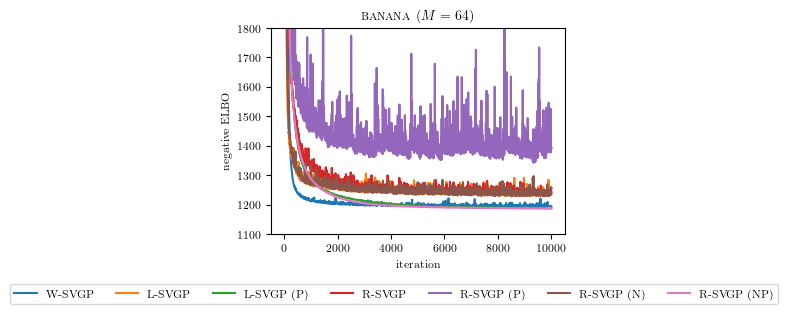

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(3.74, 3))

for i, (lml, label) in enumerate(zip(lmls, methods)):
    lml = np.vstack(lml)
    ax.plot(lml[:, 0], lml[:, 2], label=label, color=f"C{i}")

ax.set_title("\\textsc{banana} $(M = 64)$")
ax.set_xlabel("iteration")
ax.set_ylabel("negative ELBO")
ax.set_ylim(1100, 1800)

h, l = ax.get_legend_handles_labels()
fig.legend(h, l, loc="center", bbox_to_anchor=(0.5, 0), ncol=7, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)